# t-SNE Out-of-Sample Embedding: Diagnosing and Fixing the "Center Cloud" Artifact

This notebook investigates the failure of the out-of-sample t-SNE embedding implemented in `ml_experiment_utils.py`, which resulted in test points forming a diffuse cloud in the center of the 3D embedding during the ML classification experiments.

### Mathematical Diagnosis

The original `_embed_new_points` function minimized the Kullback-Leibler (KL) divergence between high-dimensional affinities $p$ and low-dimensional Student-t affinities $q$ for a test point $y$ relative to its $k$ nearest neighbors.

However, it calculated the normalization factor $Z = \sum (1 + ||y - y_k||^2)^{-1}$ **only over the $k$ neighbors**. In standard t-SNE, $Z$ is computed over all $N$ training points, which provides a **global repulsive force**. 

Because the local $k$ neighbors are typically very close, their high-dimensional affinities $p$ are relatively evenly distributed. Without the global repulsive force from the rest of the dataset, the optimizer pushed the test point $y$ extremely far away to infinity. At infinity, all distances are huge, making all local $q$ uniform, perfectly matching the uniform $p$. 

When plotted alongside the training data, these "exploded" test points forced the plot axes to expand massively (std dev > 100), causing the correctly embedded training data to look like a tiny, collapsed cloud in the center.

### The Fix

We introduce the global repulsive force by calculating the denominator $Z$ over **all training points**. The gradient now has two components:
1. **Attractive force**: Pulls $y$ towards its $k$ nearest neighbors.
2. **Repulsive force**: Pushes $y$ away from all $N$ training points.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time, os, sys
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from scipy.optimize import minimize
from sklearn.metrics import accuracy_score, r2_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

sys.path.append(os.path.abspath('.'))
import ml_experiment_utils as mlu

plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=12)
print('Setup complete.')

Setup complete.


In [2]:
# Load pre-computed global PCA scores
data = np.load('pca_data/global_forced_pca.npz')
pca_scores   = data['pca_scores']
run_labels   = data['run_labels']
st_labels    = data['st_labels']
phase_labels = data['phase_labels']

print(f'PCA scores shape: {pca_scores.shape}')

PCA scores shape: (48720, 500)


## Fixed Out-of-Sample Optimization Algorithm

Below is the corrected `_embed_new_points` function incorporating the global repulsive force.

In [3]:
def _calibrate_sigma(distances, target_perplexity, tol=1e-5, max_iter=200):
    lo, hi = 1e-10, 1e4
    for _ in range(max_iter):
        sigma = (lo + hi) / 2.0
        p = np.exp(-distances**2 / (2.0 * sigma**2))
        sum_p = p.sum()
        if sum_p < 1e-12:
            lo = sigma
            continue
        p = p / sum_p
        mask = p > 1e-12
        entropy = -np.sum(p[mask] * np.log2(p[mask]))
        perplexity = 2.0 ** entropy
        if np.abs(perplexity - target_perplexity) < tol:
            break
        if perplexity > target_perplexity:
            hi = sigma
        else:
            lo = sigma
    return sigma

def _embed_new_points_fixed(X_train_hd, train_embedding, X_test_hd, k=50, perplexity=30):
    """
    Fixed version of out-of-sample t-SNE optimization that includes 
    global repulsive forces from the entire training set.
    """
    n_test = X_test_hd.shape[0]
    n_comp = train_embedding.shape[1]
    
    print(f"Finding {k}-NN for {n_test} test points...")
    nn = NearestNeighbors(n_neighbors=k, n_jobs=-1)
    nn.fit(X_train_hd)
    distances, indices = nn.kneighbors(X_test_hd)
    
    target_perp = min(perplexity, k - 1)
    test_embedding = np.zeros((n_test, n_comp))
    
    print("Optimizing out-of-sample points with global repulsive forces...")
    t0 = time.time()
    for i in range(n_test):
        dists_i = distances[i]
        nbr_idx = indices[i]
        nbr_pos = train_embedding[nbr_idx]
        
        # 1. High-dimensional affinities (support only on k neighbors)
        sigma = _calibrate_sigma(dists_i, target_perp)
        p_k = np.exp(-dists_i**2 / (2.0 * sigma**2))
        p_k /= p_k.sum() + 1e-12
        
        # Initialize at affinity-weighted centroid of neighbors
        y0 = (p_k[:, None] * nbr_pos).sum(axis=0)
        
        # 2. Optimization Objective & Gradient
        def objective_and_grad(y):
            # Compute distances to ALL training points for global Z
            diff_all = y[None, :] - train_embedding
            sq_dist_all = np.sum(diff_all**2, axis=1)
            q_unnorm_all = 1.0 / (1.0 + sq_dist_all)
            Z = q_unnorm_all.sum() + 1e-12
            q_all = q_unnorm_all / Z
            
            # Filter for neighbors to compute KL divergence
            q_k = q_all[nbr_idx]
            q_unnorm_k = q_unnorm_all[nbr_idx]
            
            kl = np.sum(p_k * np.log((p_k + 1e-12) / (q_k + 1e-12)))
            
            # Gradient: 4 * (Attractive Force - Repulsive Force)
            attr_factor = p_k * q_unnorm_k
            grad_attr = np.sum(attr_factor[:, None] * (y[None, :] - nbr_pos), axis=0)
            
            rep_factor = q_all * q_unnorm_all
            grad_rep = np.sum(rep_factor[:, None] * diff_all, axis=0)
            
            grad = 4.0 * (grad_attr - grad_rep)
            return kl, grad
            
        result = minimize(
            objective_and_grad, y0, jac=True,
            method='L-BFGS-B',
            options={'maxiter': 300, 'ftol': 1e-12}
        )
        test_embedding[i] = result.x
        
        if (i+1) % 500 == 0:
            print(f"  Embedded {i+1}/{n_test} points...")
            
    print(f"Optimization completed in {time.time() - t0:.1f} seconds.")
    return test_embedding

## Testing the Implementation

We test this on the **Leave-Frequency-Out (Task D)** split. To ensure reasonable execution times, we will subsample the PCA data to only the first 50 components, and only test on a small fraction of the test set.

In [4]:
# 1. Create Subsampled LFO Split
lfo_train_idx, lfo_test_idx = mlu.create_leave_freq_out_split(run_labels)

X_train_lfo = pca_scores[lfo_train_idx][:, :50]
X_test_lfo  = pca_scores[lfo_test_idx][::5, :50]  # Subsample test set 5x for speed

st_train = st_labels[lfo_train_idx]
st_test  = st_labels[lfo_test_idx][::5]

# 2. Fit t-SNE on training data
print(f"Fitting t-SNE on {len(X_train_lfo)} LFO training points...")
tsne_lfo = TSNE(n_components=3, perplexity=50, learning_rate='auto', init='pca', random_state=42, n_jobs=-1)
Y_train_lfo = tsne_lfo.fit_transform(X_train_lfo)

# 3. Embed test data using the FIXED optimization
Y_test_lfo_fixed = _embed_new_points_fixed(X_train_lfo, Y_train_lfo, X_test_lfo, k=50, perplexity=30)

print(f"\nTrain Std Dev: {Y_train_lfo.std(axis=0)}")
print(f"Test  Std Dev: {Y_test_lfo_fixed.std(axis=0)}")

Fitting t-SNE on 40600 LFO training points...
Finding 50-NN for 1624 test points...
Optimizing out-of-sample points with global repulsive forces...
  Embedded 500/1624 points...
  Embedded 1000/1624 points...
  Embedded 1500/1624 points...
Optimization completed in 46.9 seconds.

Train Std Dev: [13.858982 15.886808 14.029621]
Test  Std Dev: [16.66958563 14.75609353 17.22329787]


## Visualization

If the fix is successful, both the training and test embeddings should occupy roughly the same spatial volume, with test points mapping tightly onto the manifolds corresponding to their flow states.

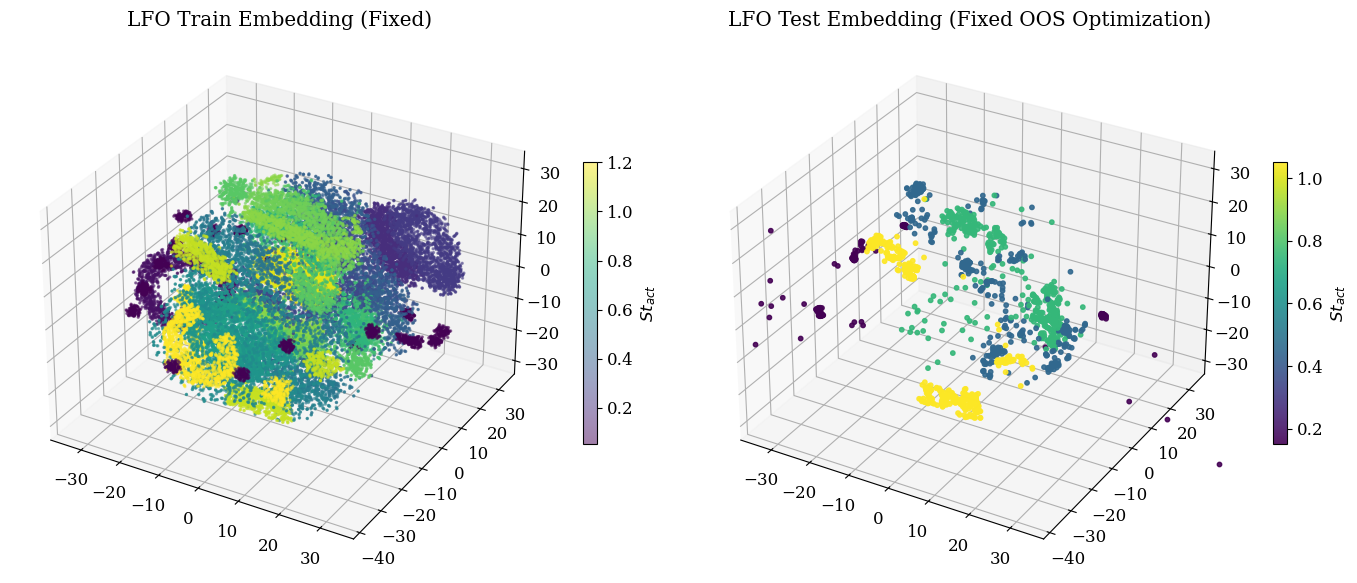

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': '3d'})

# Plot Train Embedding
ax = axes[0]
sc1 = ax.scatter(Y_train_lfo[:, 0], Y_train_lfo[:, 1], Y_train_lfo[:, 2],
                 c=st_train, cmap='viridis', s=2, alpha=0.5)
ax.set_title("LFO Train Embedding (Fixed)")
fig.colorbar(sc1, ax=ax, shrink=0.5, label="$St_{act}$")

# Plot Test Embedding
ax = axes[1]
sc2 = ax.scatter(Y_test_lfo_fixed[:, 0], Y_test_lfo_fixed[:, 1], Y_test_lfo_fixed[:, 2],
                 c=st_test, cmap='viridis', s=10, alpha=0.9)
ax.set_title("LFO Test Embedding (Fixed OOS Optimization)")
fig.colorbar(sc2, ax=ax, shrink=0.5, label="$St_{act}$")

# Keep axis limits identical to verify they occupy the same space
for ax in axes:
    ax.set_xlim(Y_train_lfo[:, 0].min(), Y_train_lfo[:, 0].max())
    ax.set_ylim(Y_train_lfo[:, 1].min(), Y_train_lfo[:, 1].max())
    ax.set_zlim(Y_train_lfo[:, 2].min(), Y_train_lfo[:, 2].max())

plt.tight_layout()
plt.savefig('fixed_tsne_oos_test.png', dpi=300, bbox_inches='tight')
plt.show()